install library

In [30]:
pip install pandas numpy scipy statsmodels matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Step 1: Notebook setup

In [31]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.options.display.float_format = '{:.4f}'.format

In [32]:
#Retype
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.options.display.float_format = '{:.4f}'.format

Step 2: Load Data

In [33]:
df = pd.read_csv(r"C:\Users\phanh\data_analysis\p_projects\au_rokt\raw_data\[AU] Rokt\rokt_hKllMfFFdA.csv")

# Verify shape
print(f"Shape: {df.shape}")    # expect (889091, 11)
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
df.head()

Shape: (889091, 11)

Dtypes:
agegroup                 str
bidprice_usd         float64
campaigntimestamp        str
cohort                 int64
device                   str
gender                   str
group                    str
sessionid                str
userhash                 str
value                float64
verticalname             str
dtype: object

Null counts:
agegroup                  0
bidprice_usd              0
campaigntimestamp         0
cohort                    0
device                  122
gender                90630
group                     0
sessionid                 0
userhash                  0
value                873156
verticalname              0
dtype: int64


,agegroup,bidprice_usd,campaigntimestamp,cohort,device,gender,group,sessionid,userhash,value,verticalname
0,26-30,0.0000,2020-02-01 00:01:39,202002,mobile,f,treatment,37348334365,e7j+F6Pk3JiuQi+y3HI0xX7mzuSY5tTohpQM0FZIWPU=,NaN,Ticketing
1,36-40,0.0000,2020-02-01 00:04:09,202002,Mobile,f,treatment,37348334755,217xmeBlQVPlC4vVXRdpSFG1uvbA2ET6BL/TaPAK7mo=,NaN,Media and Entertainment
2,31-35,0.0000,2020-02-01 00:04:37,202002,Mobile,f,treatment,37349334794,YZm04BwARD+mj0R0MEYuKeAf4l1ZIRsge2LumlsnmTQ=,NaN,Media and Entertainment
3,26-30,0.0000,2020-02-01 00:04:41,202002,Mobile,f,treatment,37348334834,TR25fI0N1lOqSu2hadffCZ+SNIA6iY9BHAnIXAVXuxM=,NaN,Ticketing
4,36-40,0.0000,2020-02-01 00:04:54,202002,Other,f,treatment,37348334883,+ufGey+TPBU8o2SjY+AXrNvocVGXKjQ+H8pqq7jQ8y8=,NaN,Media and Entertainment


Step 3: Explore Before Cleaning

In [34]:
# Check unqiue values per column
for col in ['group', 'device', 'gender', 'cohort', 'agegroup']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

#Check value column (This defines "converted")
print(f"\nvalue non-null: {df['value'].notna().sum()}")
print(f"value empty string: {(df['value'] == '').sum()}")


group:
group
treatment    756149
control      132942
Name: count, dtype: int64

device:
device
Mobile     470187
Desktop    171011
mobile     110537
Tablet      99562
Other       37672
NaN           122
Name: count, dtype: int64

gender:
gender
f      643553
m      154908
NaN     90630
Name: count, dtype: int64

cohort:
cohort
202006    302757
202005    214188
202004    162761
202002    115940
202003     93444
203902         1
Name: count, dtype: int64

agegroup:
agegroup
18-25    368592
31-35    140313
36-40    126151
26-30    100159
41-45     83007
46-55     43915
56-65     25356
65+        1598
Name: count, dtype: int64

value non-null: 15935
value empty string: 0


Step 4: Data Cleaning

In [35]:
# 1. Normalize device casing
df['device'] = df['device'].str.strip().str.title()

# 2. handle empty devices
df['device'] = df['device'].replace('', 'Unknown')

# 3. Handle enpty gender
df['gender'] = df['gender'].replace('', 'unknown')

# 4.Remove invalid cohort
print(f"Before: {len(df)}")
df = df[df['cohort'] != 203902]
print(f"After: {len(df)}")

# 5. Create 'converted' flag
df['converted'] = df['value'].notna() & (df['value'] != '')

# 6. Parse timestamp
df['campaigntimestamp'] = pd.to_datetime(df['campaigntimestamp'])


Before: 889091
After: 889090


In [36]:
df.head()

,agegroup,bidprice_usd,campaigntimestamp,cohort,device,gender,group,sessionid,userhash,value,verticalname,converted
0,26-30,0.0000,2020-02-01 00:01:39,202002,Mobile,f,treatment,37348334365,e7j+F6Pk3JiuQi+y3HI0xX7mzuSY5tTohpQM0FZIWPU=,NaN,Ticketing,False
1,36-40,0.0000,2020-02-01 00:04:09,202002,Mobile,f,treatment,37348334755,217xmeBlQVPlC4vVXRdpSFG1uvbA2ET6BL/TaPAK7mo=,NaN,Media and Entertainment,False
2,31-35,0.0000,2020-02-01 00:04:37,202002,Mobile,f,treatment,37349334794,YZm04BwARD+mj0R0MEYuKeAf4l1ZIRsge2LumlsnmTQ=,NaN,Media and Entertainment,False
3,26-30,0.0000,2020-02-01 00:04:41,202002,Mobile,f,treatment,37348334834,TR25fI0N1lOqSu2hadffCZ+SNIA6iY9BHAnIXAVXuxM=,NaN,Ticketing,False
4,36-40,0.0000,2020-02-01 00:04:54,202002,Other,f,treatment,37348334883,+ufGey+TPBU8o2SjY+AXrNvocVGXKjQ+H8pqq7jQ8y8=,NaN,Media and Entertainment,False


Step 5: Validate Cleaning

In [37]:
# Confirm device is clean
print(df['device'].value_counts())
# Should show: Mobile, Desktop, Tablet, Other (no lowercase 'mobile')

# Confirm cohort is clean
print(df['cohort'].value_counts().sort_index())
# Should show: 202002-202006 only

# Confirm converted flag
print(f"Converted rows: {df['converted'].sum()}")
# Should be around 15,935

device
Mobile     580723
Desktop    171011
Tablet      99562
Other       37672
Name: count, dtype: int64
cohort
202002    115940
202003     93444
202004    162761
202005    214188
202006    302757
Name: count, dtype: int64
Converted rows: 15935


Step 6: Calculate Overall Metrics

In [38]:
#---Conversion Rate
def calc_cr(group_df):
    users = group_df['userhash'].nunique()
    converted = group_df[group_df['converted']]['userhash'].nunique()
    return converted/users, converted, users

cr_t, conv_t, users_t = calc_cr(df[df['group'] == 'treatment'])
cr_c, conv_c, users_c = calc_cr(df[df['group'] == 'control'])
uplift = (cr_t - cr_c) / cr_c

print(f"CR Treatment: {cr_t: .4%}    ({conv_t}/{users_t})")
print(f"CR Control:   {cr_c:.4%}  ({conv_c}/{users_c})")
print(f"CR Uplift:    {uplift: .2%}")

#----Value Per transaction---
def calc_vpt(group_df):
    bid_sum = group_df['bidprice_usd'].sum()
    sessions = group_df['sessionid'].nunique()
    return bid_sum / sessions 

vpt_t = calc_vpt(df[df['group'] == 'treatment'])
vpt_c = calc_vpt(df[df['group'] == 'control'])

print(f"\nVPT Treatment: ${vpt_t: .4f}")
print(f"VPT Control: ${vpt_c: .4f}")

CR Treatment:  2.2261%    (12833/576471)
CR Control:   1.9540%  (2379/121750)
CR Uplift:     13.93%

VPT Treatment: $ 0.0796
VPT Control: $ 0.0000


task 3 - Conversion rate, VPT & Uplift Per Cohort

In [39]:
#Build cohort summary
results = []
for cohort in sorted(df['cohort'].unique()):
    for group in ['treatment', 'control']:
        mask = (df['cohort'] == cohort) & (df['group'] == group)
        sub = df[mask]
        cr_val, conv, users = calc_cr(sub)
        vpt_val = calc_vpt(sub)
        results.append({
            'cohort': cohort,
            'group': group,
            'users': users,
            'converted': conv,
            'cr': cr_val,
            'vpt': vpt_val
        })
cohort_df = pd.DataFrame(results)

#Pivot for uplift calc
pivot = cohort_df.pivot(index='cohort', columns='group', values='cr')
pivot['uplift'] = (pivot['treatment'] - pivot['control']) / pivot['control']
print(pivot)


group   control  treatment  uplift
cohort                            
202002   0.0235     0.0300  0.2758
202003   0.0231     0.0294  0.2712
202004   0.0188     0.0210  0.1158
202005   0.0156     0.0182  0.1630
202006   0.0121     0.0153  0.2655


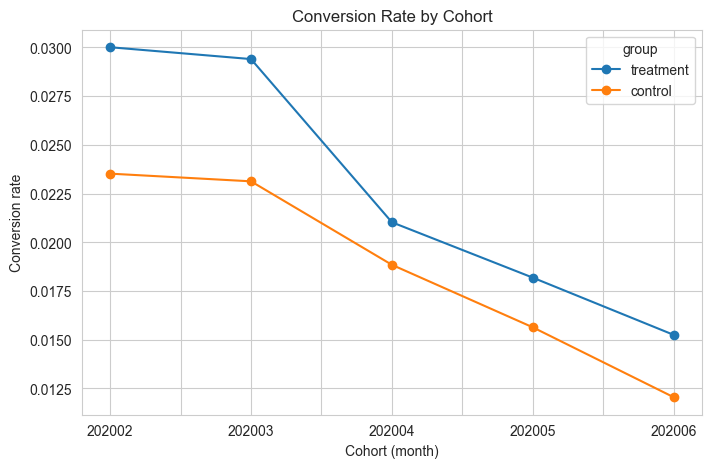

In [40]:
#suggested chart

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (8,5))
pivot.index = pivot.index.astype(str)
pivot[['treatment', 'control']].plot(marker='o', ax=ax)
ax.set_title('Conversion Rate by Cohort')
ax.set_ylabel('Conversion rate')
ax.set_xlabel('Cohort (month)')
plt.tight_layout
plt.show()

Task 4- Positive or Negative Impact

In [41]:
diff = cr_t - cr_c
direction = "POSITIVE" if cr_t > cr_c else "NEGATIVE"

print(f"CR Treatment: {cr_t:.4%}")
print(f"CR Control {cr_c:.4%}")
print(f"Absolute difference: {diff:.4%}")
print(f"Relative uplift: {uplift:.2%}")
print(f"\nRokt has a {direction} impact on conversion rate.")

CR Treatment: 2.2261%
CR Control 1.9540%
Absolute difference: 0.2721%
Relative uplift: 13.93%

Rokt has a POSITIVE impact on conversion rate.


Task 5- How Confident Are We? (z-test for proportions)
What this step is for: Task 4 gave you a verdict (POSITIVE), but is that gap real or could it be random luck - like flipping two coins and getting slightly different numbers of heads by chance? The z-test answers exactly that: "if treatment and control were truly identical, how likely is it we'd see a gap this big just by accident?" If that probability is very low, you can trust the uplift is genuine.

In [42]:
from statsmodels.stats.proportion import proportions_ztest

#count = converted users, nobs = total users
count = [conv_t, conv_c]
nobs = [users_t, users_c]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nStatistically significant (p <0.05).")
    print("We reject H0 - the difference is REAL.")
else:
    print("\nNot significant (p>=0.05).")
    print("Cannot rule out chance.")

Z-statistic: 5.9100
P-value: 0.000000

Statistically significant (p <0.05).
We reject H0 - the difference is REAL.


In [43]:
#z-test per cohort
print("Cohort Z-stat    P-value     Significant?")
print("-" *45)

for cohort in sorted(df['cohort'].unique()):
    t = df[(df['cohort'] == cohort) & (df['group'] == 'treatment')]
    c = df[(df['cohort'] == cohort) & (df['group'] == 'control')]

    conv = [t[t['converted']]['userhash'].nunique(),c[c['converted']]['userhash'].nunique()]

    tot = [t['userhash'].nunique(), c['userhash'].nunique()]

    z, p = proportions_ztest(conv, tot)
    sig = "YES" if p < 0.05 else "no"
    print(f"{cohort} {z:6.3f} {p:8.5f} {sig}")

Cohort Z-stat    P-value     Significant?
---------------------------------------------
202002  5.580  0.00000 YES
202003  4.969  0.00000 YES
202004  2.346  0.01896 YES
202005  2.495  0.01259 YES
202006  4.027  0.00006 YES


task 6 - Any Other Metrics Showing Impact?

6a — Conversion by device (introduces groupby)

In [44]:
# Conversion rate by device and group
device_cr = df.groupby(['device', 'group']).apply(
    lambda g: g[g['converted']]['userhash'].nunique() / g['userhash'].nunique()
)

device_pivot = device_cr.unstack()
device_pivot['uplift'] = (device_pivot['treatment'] - device_pivot['control']) / device_pivot['control']
print(device_pivot)


group    control  treatment  uplift
device                             
Desktop   0.0239     0.0309  0.2914
Mobile    0.0182     0.0194  0.0643
Other     0.0187     0.0233  0.2455
Tablet    0.0170     0.0207  0.2149


6b. Visualize it

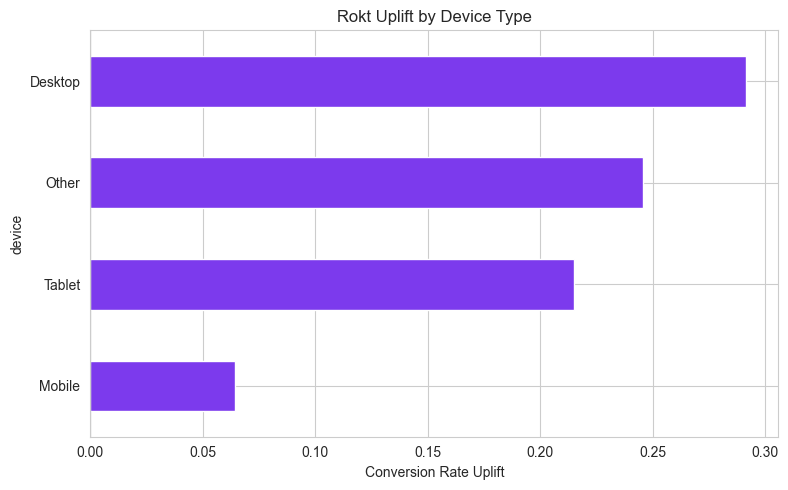

In [45]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))

device_pivot['uplift'].sort_values().plot(
    kind='barh', ax=ax, color='#7C3AED'
)

ax.set_xlabel('Conversion Rate Uplift')
ax.set_title('Rokt Uplift by Device Type')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

6c- Revenue impact estimate

In [50]:
#Extra conversions attribute to Rokt
expected_conv_if_control = users_t * cr_c
actual_conv = conv_t
extra_conversion = actual_conv - expected_conv_if_control

#Average conversion value (from rows that did convert)
avg_value = df[df['converted']]['value'].astype(float).mean()

extra_revenue = extra_conversion * avg_value

print(f"Extra conversions from Rokt:{extra_conversion:,.0f}")
print(f"Avg conversion value:${avg_value:,.2f}")
print(f"Estimated extra revenue:${extra_revenue:,.2f}")

Extra conversions from Rokt:1,569
Avg conversion value:$150.29
Estimated extra revenue:$235,770.50
